In [2]:
import pandas as pd
#opening the data file in read mode
df = pd.read_csv('Sentiment Analysis Dataset.tsv', sep='\t')
print(df)

            id  sentiment                                             review
0       5814_8          1  With all this stuff going down at the moment w...
1       2381_9          1  \The Classic War of the Worlds\" by Timothy Hi...
2       7759_3          0  The film starts with a manager (Nicholas Bell)...
3       3630_4          0  It must be assumed that those who praised this...
4       9495_8          1  Superbly trashy and wondrously unpretentious 8...
...        ...        ...                                                ...
24995   3453_3          0  It seems like more consideration has gone into...
24996   5064_1          0  I don't believe they made this film. Completel...
24997  10905_3          0  Guy is a loser. Can't get girls, needs to buil...
24998  10194_3          0  This 30 minute documentary Buñuel made in the ...
24999   8478_8          1  I saw this movie as a child and it broke my he...

[25000 rows x 3 columns]


In [3]:
reviews=df.iloc[:,2].values
labels=df.iloc[:,1].values


In [4]:
#parsing html
from bs4 import BeautifulSoup
import re

def parseHtml(html):
  soup = BeautifulSoup(html, 'html.parser')
  return soup.get_text()

def removeDigits(string):
  for i in range(10):
    string=string.replace(str(i),' ')
  return string

#removing html
reviews=list(map(parseHtml, reviews))

#removing digits
reviews=list(map(removeDigits, reviews))


In [5]:
#tokenizing
import nltk
nltk.download('punkt')
tokenizedText=[nltk.word_tokenize(item) for item in reviews]


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kesh2\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
#removing punctuation
punc = '''!()-[]{};:'"\, <>./?@#$%^&*_~'''
tokenizedText= [[word for word in review if word not in punc] for review in tokenizedText]


<>:2: SyntaxWarning: invalid escape sequence '\,'
<>:2: SyntaxWarning: invalid escape sequence '\,'
C:\Users\kesh2\AppData\Local\Temp\ipykernel_11020\404723166.py:2: SyntaxWarning: invalid escape sequence '\,'
  punc = '''!()-[]{};:'"\, <>./?@#$%^&*_~'''


In [7]:
import numpy as np
#splitting the Dataset into train and test set
totalRows=len(tokenizedText)

splitRatio=0.75
splitPoint=int(splitRatio*totalRows)

trainReviews=tokenizedText[:splitPoint]
trainLabels=labels[:splitPoint]
testReviews=tokenizedText[splitPoint:]
testLabels=labels[splitPoint:]

In [8]:
#learning word embeddings on training data using Gensim library
from gensim.models import Word2Vec, KeyedVectors
import nltk

embeddingsSize=128

# Train multiple Word2Vec models with different context window sizes
print("Training Word2Vec models with different window sizes...")

model_w3 = Word2Vec(trainReviews, vector_size=embeddingsSize, window=3, min_count=1, workers=4)
print("✓ Word2Vec model with window=3 trained")

model_w5 = Word2Vec(trainReviews, vector_size=embeddingsSize, window=5, min_count=1, workers=4)
print("✓ Word2Vec model with window=5 trained")

model_w7 = Word2Vec(trainReviews, vector_size=embeddingsSize, window=7, min_count=1, workers=4)
print("✓ Word2Vec model with window=7 trained")

######################Training of Word Embeddings Vectors Completed#########

Training Word2Vec models with different window sizes...
✓ Word2Vec model with window=3 trained
✓ Word2Vec model with window=5 trained
✓ Word2Vec model with window=7 trained


In [9]:
import numpy as np

def getVectors(dataset, model):
  """Get average word vectors for each review using a specific Word2Vec model"""
  vectors = []
  for dataItem in dataset:
    singleDataItemEmbedding = np.zeros(embeddingsSize)
    wordCount = 0
    for word in dataItem:
      if word in model.wv.key_to_index:
        singleDataItemEmbedding = singleDataItemEmbedding + model.wv[word]
        wordCount = wordCount + 1
    
    if wordCount > 0:
      singleDataItemEmbedding = singleDataItemEmbedding / wordCount
    vectors.append(singleDataItemEmbedding)
  return vectors

# Generate vectors for all Word2Vec models
print("Generating vectors for Word2Vec models...")

trainReviewVectors_w3 = getVectors(trainReviews, model_w3)
testReviewVectors_w3 = getVectors(testReviews, model_w3)
print("✓ Vectors generated for window=3")

trainReviewVectors_w5 = getVectors(trainReviews, model_w5)
testReviewVectors_w5 = getVectors(testReviews, model_w5)
print("✓ Vectors generated for window=5")

trainReviewVectors_w7 = getVectors(trainReviews, model_w7)
testReviewVectors_w7 = getVectors(testReviews, model_w7)
print("✓ Vectors generated for window=7")

Generating vectors for Word2Vec models...
✓ Vectors generated for window=3
✓ Vectors generated for window=5
✓ Vectors generated for window=7


In [10]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

print("\nGenerating TF-IDF vectors...")

# Convert tokenized reviews back to strings for TF-IDF
trainReviewsStr = [' '.join(review) for review in trainReviews]
testReviewsStr = [' '.join(review) for review in testReviews]

# Create TF-IDF vectorizer with max_features to match embedding size for fair comparison
tfidf = TfidfVectorizer(max_features=embeddingsSize)
trainReviewVectors_tfidf = tfidf.fit_transform(trainReviewsStr).toarray()
testReviewVectors_tfidf = tfidf.transform(testReviewsStr).toarray()
print("✓ TF-IDF vectors generated")

print(f"\nAll vectorization methods ready!")
print(f"Vector dimension: {embeddingsSize}")


Generating TF-IDF vectors...
✓ TF-IDF vectors generated

All vectorization methods ready!
Vector dimension: 128


# Comparative Analysis: Multiple Vectorization Methods

This section compares **4 different vectorization methods**:
1. **Word2Vec (window=3)** - Smaller context window, captures local word relationships
2. **Word2Vec (window=5)** - Medium context window, balanced approach
3. **Word2Vec (window=7)** - Larger context window, captures broader context
4. **TF-IDF** - Traditional statistical method based on term frequency

Each method is tested with **4 machine learning classifiers**:
- **Naive Bayes (NB)** - Probabilistic classifier
- **Neural Network (NN)** - Multi-layer perceptron
- **Random Forest (RF)** - Ensemble method
- **K-Nearest Neighbors (KNN)** - Instance-based learning

**Total combinations tested: 16** (4 vectorization methods × 4 classifiers)

In [11]:
# Define evaluation metrics and helper functions
from sklearn.metrics import accuracy_score, precision_recall_fscore_support as score
from sklearn.metrics import f1_score, confusion_matrix

def printResults(y_true, y_predicted):
    """Display comprehensive evaluation metrics"""
    print("Accuracy= ", accuracy_score(y_true, y_predicted))
    
    # Print confusion matrix
    cm = confusion_matrix(y_true, y_predicted)
    print("Confusion Matrix:")
    print(cm)
    
    precision, recall, fscore, support = score(y_true, y_predicted)
    
    print('###########################################')
    print('precision: {}'.format(precision))  
    print('recall: {}'.format(recall))
    print('fscore: {}'.format(fscore))
    print('support: {}'.format(support))
    print('###########################################')
    
    print('Macro F1: ',f1_score(y_true, y_predicted, average='macro'))
    print('Micro F1: ', f1_score(y_true, y_predicted, average='micro'))

In [12]:
# Store all results for comparison
results_comparison = []

def runAllClassifiers(trainVectors, testVectors, method_name):
    """Run all 4 classifiers on given vectors and store results"""
    print(f"\n{'='*80}")
    print(f"RUNNING CLASSIFIERS FOR: {method_name}")
    print(f"{'='*80}\n")
    
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.naive_bayes import MultinomialNB
    from sklearn.neural_network import MLPClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.neighbors import KNeighborsClassifier
    
    method_results = {'method': method_name}
    
    # 1. Naive Bayes
    print(f"{'='*80}")
    print(f"NAIVE BAYES - {method_name}")
    print(f"{'='*80}")
    scaler = MinMaxScaler()
    scaledTrainX = scaler.fit_transform(trainVectors)
    scaledTestX = scaler.transform(testVectors)
    
    clfNB = MultinomialNB()
    clfNB.fit(scaledTrainX, trainLabels)
    testLabelsPredicted = list(clfNB.predict(scaledTestX))
    nb_accuracy = accuracy_score(testLabels, testLabelsPredicted)
    nb_f1 = f1_score(testLabels, testLabelsPredicted, average='macro')
    printResults(testLabels, testLabelsPredicted)
    method_results['NB'] = {'accuracy': nb_accuracy, 'f1': nb_f1}
    
    # 2. Neural Network
    print(f"\n{'='*80}")
    print(f"NEURAL NETWORK - {method_name}")
    print(f"{'='*80}")
    clfMLP = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=500)
    clfMLP.fit(trainVectors, trainLabels)
    testLabelsPredicted = list(clfMLP.predict(testVectors))
    nn_accuracy = accuracy_score(testLabels, testLabelsPredicted)
    nn_f1 = f1_score(testLabels, testLabelsPredicted, average='macro')
    printResults(testLabels, testLabelsPredicted)
    method_results['NN'] = {'accuracy': nn_accuracy, 'f1': nn_f1}
    
    # 3. Random Forest
    print(f"\n{'='*80}")
    print(f"RANDOM FOREST - {method_name}")
    print(f"{'='*80}")
    clfRF = RandomForestClassifier(n_estimators=1000, random_state=42)
    clfRF.fit(trainVectors, trainLabels)
    testLabelsPredicted = list(clfRF.predict(testVectors))
    rf_accuracy = accuracy_score(testLabels, testLabelsPredicted)
    rf_f1 = f1_score(testLabels, testLabelsPredicted, average='macro')
    printResults(testLabels, testLabelsPredicted)
    method_results['RF'] = {'accuracy': rf_accuracy, 'f1': rf_f1}
    
    # 4. KNN
    print(f"\n{'='*80}")
    print(f"KNN - {method_name}")
    print(f"{'='*80}")
    clfKNN = KNeighborsClassifier(n_neighbors=3)
    clfKNN.fit(trainVectors, trainLabels)
    testLabelsPredicted = list(clfKNN.predict(testVectors))
    knn_accuracy = accuracy_score(testLabels, testLabelsPredicted)
    knn_f1 = f1_score(testLabels, testLabelsPredicted, average='macro')
    printResults(testLabels, testLabelsPredicted)
    method_results['KNN'] = {'accuracy': knn_accuracy, 'f1': knn_f1}
    
    results_comparison.append(method_results)
    return method_results

In [13]:
# Run classifiers on Word2Vec (window=3)
runAllClassifiers(trainReviewVectors_w3, testReviewVectors_w3, "Word2Vec (window=3)")


RUNNING CLASSIFIERS FOR: Word2Vec (window=3)

NAIVE BAYES - Word2Vec (window=3)
Accuracy=  0.63088
Confusion Matrix:
[[2020 1084]
 [1223 1923]]
###########################################
precision: [0.62288005 0.63950782]
recall: [0.6507732  0.61125238]
fscore: [0.63652119 0.62506095]
support: [3104 3146]
###########################################
Macro F1:  0.6307910684969853
Micro F1:  0.63088

NEURAL NETWORK - Word2Vec (window=3)
Accuracy=  0.80544
Confusion Matrix:
[[2303  801]
 [ 415 2731]]
###########################################
precision: [0.8473142  0.77321631]
recall: [0.74194588 0.86808646]
fscore: [0.79113707 0.81790955]
support: [3104 3146]
###########################################
Macro F1:  0.8045233100294255
Micro F1:  0.80544

RANDOM FOREST - Word2Vec (window=3)
Accuracy=  0.76096
Confusion Matrix:
[[2312  792]
 [ 702 2444]]
###########################################
precision: [0.76708693 0.7552534 ]
recall: [0.74484536 0.7768595 ]
fscore: [0.75580255 0.76590

{'method': 'Word2Vec (window=3)',
 'NB': {'accuracy': 0.63088, 'f1': 0.6307910684969853},
 'NN': {'accuracy': 0.80544, 'f1': 0.8045233100294255},
 'RF': {'accuracy': 0.76096, 'f1': 0.7608533275745193},
 'KNN': {'accuracy': 0.68016, 'f1': 0.6798354217609512}}

In [14]:
# Run classifiers on Word2Vec (window=5)
runAllClassifiers(trainReviewVectors_w5, testReviewVectors_w5, "Word2Vec (window=5)")


RUNNING CLASSIFIERS FOR: Word2Vec (window=5)

NAIVE BAYES - Word2Vec (window=5)
Accuracy=  0.63888
Confusion Matrix:
[[2041 1063]
 [1194 1952]]
###########################################
precision: [0.6309119  0.64742952]
recall: [0.65753866 0.62047044]
fscore: [0.64395015 0.63366337]
support: [3104 3146]
###########################################
Macro F1:  0.6388067581012715
Micro F1:  0.63888

NEURAL NETWORK - Word2Vec (window=5)
Accuracy=  0.82112
Confusion Matrix:
[[2449  655]
 [ 463 2683]]
###########################################
precision: [0.84100275 0.80377472]
recall: [0.78898196 0.85282899]
fscore: [0.81416223 0.82757557]
support: [3104 3146]
###########################################
Macro F1:  0.8208689023389817
Micro F1:  0.82112

RANDOM FOREST - Word2Vec (window=5)
Accuracy=  0.7648
Confusion Matrix:
[[2321  783]
 [ 687 2459]]
###########################################
precision: [0.77160904 0.75848242]
recall: [0.74774485 0.78162746]
fscore: [0.75948953 0.769881

{'method': 'Word2Vec (window=5)',
 'NB': {'accuracy': 0.63888, 'f1': 0.6388067581012715},
 'NN': {'accuracy': 0.82112, 'f1': 0.8208689023389817},
 'RF': {'accuracy': 0.7648, 'f1': 0.7646852778606484},
 'KNN': {'accuracy': 0.69296, 'f1': 0.6928560133318736}}

In [15]:
# Run classifiers on Word2Vec (window=7)
runAllClassifiers(trainReviewVectors_w7, testReviewVectors_w7, "Word2Vec (window=7)")


RUNNING CLASSIFIERS FOR: Word2Vec (window=7)

NAIVE BAYES - Word2Vec (window=7)
Accuracy=  0.6536
Confusion Matrix:
[[2061 1043]
 [1122 2024]]
###########################################
precision: [0.64750236 0.65992827]
recall: [0.66398196 0.64335664]
fscore: [0.65563862 0.6515371 ]
support: [3104 3146]
###########################################
Macro F1:  0.6535878595015592
Micro F1:  0.6536

NEURAL NETWORK - Word2Vec (window=7)
Accuracy=  0.82176
Confusion Matrix:
[[2484  620]
 [ 494 2652]]
###########################################
precision: [0.83411686 0.81051345]
recall: [0.80025773 0.84297521]
fscore: [0.81683657 0.82642568]
support: [3104 3146]
###########################################
Macro F1:  0.8216311223500085
Micro F1:  0.82176

RANDOM FOREST - Word2Vec (window=7)
Accuracy=  0.7728
Confusion Matrix:
[[2347  757]
 [ 663 2483]]
###########################################
precision: [0.77973422 0.76635802]
recall: [0.75612113 0.7892562 ]
fscore: [0.76774616 0.77763858

{'method': 'Word2Vec (window=7)',
 'NB': {'accuracy': 0.6536, 'f1': 0.6535878595015592},
 'NN': {'accuracy': 0.82176, 'f1': 0.8216311223500085},
 'RF': {'accuracy': 0.7728, 'f1': 0.7726923703829146},
 'KNN': {'accuracy': 0.70496, 'f1': 0.7048400394359318}}

In [16]:
# Run classifiers on TF-IDF
runAllClassifiers(trainReviewVectors_tfidf, testReviewVectors_tfidf, "TF-IDF")


RUNNING CLASSIFIERS FOR: TF-IDF

NAIVE BAYES - TF-IDF
Accuracy=  0.7272
Confusion Matrix:
[[2259  845]
 [ 860 2286]]
###########################################
precision: [0.7242706  0.73011817]
recall: [0.72777062 0.726637  ]
fscore: [0.72601639 0.72837343]
support: [3104 3146]
###########################################
Macro F1:  0.727194908802266
Micro F1:  0.7272

NEURAL NETWORK - TF-IDF
Accuracy=  0.72608
Confusion Matrix:
[[2419  685]
 [1027 2119]]
###########################################
precision: [0.7019733  0.75570613]
recall: [0.77931701 0.67355372]
fscore: [0.73862595 0.71226891]
support: [3104 3146]
###########################################
Macro F1:  0.7254474308807493
Micro F1:  0.72608

RANDOM FOREST - TF-IDF
Accuracy=  0.7352
Confusion Matrix:
[[2291  813]
 [ 842 2304]]
###########################################
precision: [0.73124801 0.73917228]
recall: [0.7380799  0.73235855]
fscore: [0.73464807 0.73574964]
support: [3104 3146]
##############################

{'method': 'TF-IDF',
 'NB': {'accuracy': 0.7272, 'f1': 0.727194908802266},
 'NN': {'accuracy': 0.72608, 'f1': 0.7254474308807493},
 'RF': {'accuracy': 0.7352, 'f1': 0.7351988543643235},
 'KNN': {'accuracy': 0.63392, 'f1': 0.6336161065434114}}

In [17]:
# Display comprehensive results comparison
import pandas as pd

print("\n" + "="*100)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*100 + "\n")

# Create comparison DataFrame
comparison_data = []
for result in results_comparison:
    method = result['method']
    for classifier in ['NB', 'NN', 'RF', 'KNN']:
        comparison_data.append({
            'Vectorization Method': method,
            'Classifier': classifier,
            'Accuracy': f"{result[classifier]['accuracy']:.4f}",
            'Macro F1-Score': f"{result[classifier]['f1']:.4f}"
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "="*100)
print("BEST PERFORMERS")
print("="*100 + "\n")

# Find best combinations
best_accuracy_idx = comparison_df['Accuracy'].astype(float).idxmax()
best_f1_idx = comparison_df['Macro F1-Score'].astype(float).idxmax()

print(f"Best Accuracy: {comparison_df.loc[best_accuracy_idx, 'Vectorization Method']} + "
      f"{comparison_df.loc[best_accuracy_idx, 'Classifier']} = "
      f"{comparison_df.loc[best_accuracy_idx, 'Accuracy']}")

print(f"Best F1-Score: {comparison_df.loc[best_f1_idx, 'Vectorization Method']} + "
      f"{comparison_df.loc[best_f1_idx, 'Classifier']} = "
      f"{comparison_df.loc[best_f1_idx, 'Macro F1-Score']}")

# Average performance by vectorization method
print("\n" + "="*100)
print("AVERAGE PERFORMANCE BY VECTORIZATION METHOD")
print("="*100 + "\n")

avg_by_method = comparison_df.groupby('Vectorization Method').agg({
    'Accuracy': lambda x: f"{x.astype(float).mean():.4f}",
    'Macro F1-Score': lambda x: f"{x.astype(float).mean():.4f}"
})
print(avg_by_method)

# Average performance by classifier
print("\n" + "="*100)
print("AVERAGE PERFORMANCE BY CLASSIFIER")
print("="*100 + "\n")

avg_by_classifier = comparison_df.groupby('Classifier').agg({
    'Accuracy': lambda x: f"{x.astype(float).mean():.4f}",
    'Macro F1-Score': lambda x: f"{x.astype(float).mean():.4f}"
})
print(avg_by_classifier)


COMPREHENSIVE RESULTS COMPARISON

Vectorization Method Classifier Accuracy Macro F1-Score
 Word2Vec (window=3)         NB   0.6309         0.6308
 Word2Vec (window=3)         NN   0.8054         0.8045
 Word2Vec (window=3)         RF   0.7610         0.7609
 Word2Vec (window=3)        KNN   0.6802         0.6798
 Word2Vec (window=5)         NB   0.6389         0.6388
 Word2Vec (window=5)         NN   0.8211         0.8209
 Word2Vec (window=5)         RF   0.7648         0.7647
 Word2Vec (window=5)        KNN   0.6930         0.6929
 Word2Vec (window=7)         NB   0.6536         0.6536
 Word2Vec (window=7)         NN   0.8218         0.8216
 Word2Vec (window=7)         RF   0.7728         0.7727
 Word2Vec (window=7)        KNN   0.7050         0.7048
              TF-IDF         NB   0.7272         0.7272
              TF-IDF         NN   0.7261         0.7254
              TF-IDF         RF   0.7352         0.7352
              TF-IDF        KNN   0.6339         0.6336

BEST PERFORM

In [18]:
import pickle
import os

# Create models directory if it doesn't exist
models_dir = 'saved_models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

print("\nSaving all models...\n")

# Save all Word2Vec models
model_w3.save(os.path.join(models_dir, 'word2vec_model_w3.model'))
print("✓ Word2Vec model (window=3) saved")

model_w5.save(os.path.join(models_dir, 'word2vec_model_w5.model'))
print("✓ Word2Vec model (window=5) saved")

model_w7.save(os.path.join(models_dir, 'word2vec_model_w7.model'))
print("✓ Word2Vec model (window=7) saved")

# Save TF-IDF vectorizer
with open(os.path.join(models_dir, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)
print("✓ TF-IDF vectorizer saved")

# Save embedding size and results comparison
with open(os.path.join(models_dir, 'embeddings_size.pkl'), 'wb') as f:
    pickle.dump(embeddingsSize, f)
print("✓ Embeddings size saved")

with open(os.path.join(models_dir, 'results_comparison.pkl'), 'wb') as f:
    pickle.dump(results_comparison, f)
print("✓ Results comparison saved")

print("\n✓ All models and results saved successfully in 'saved_models/' directory!")


Saving all models...

✓ Word2Vec model (window=3) saved
✓ Word2Vec model (window=5) saved
✓ Word2Vec model (window=7) saved
✓ TF-IDF vectorizer saved
✓ Embeddings size saved
✓ Results comparison saved

✓ All models and results saved successfully in 'saved_models/' directory!


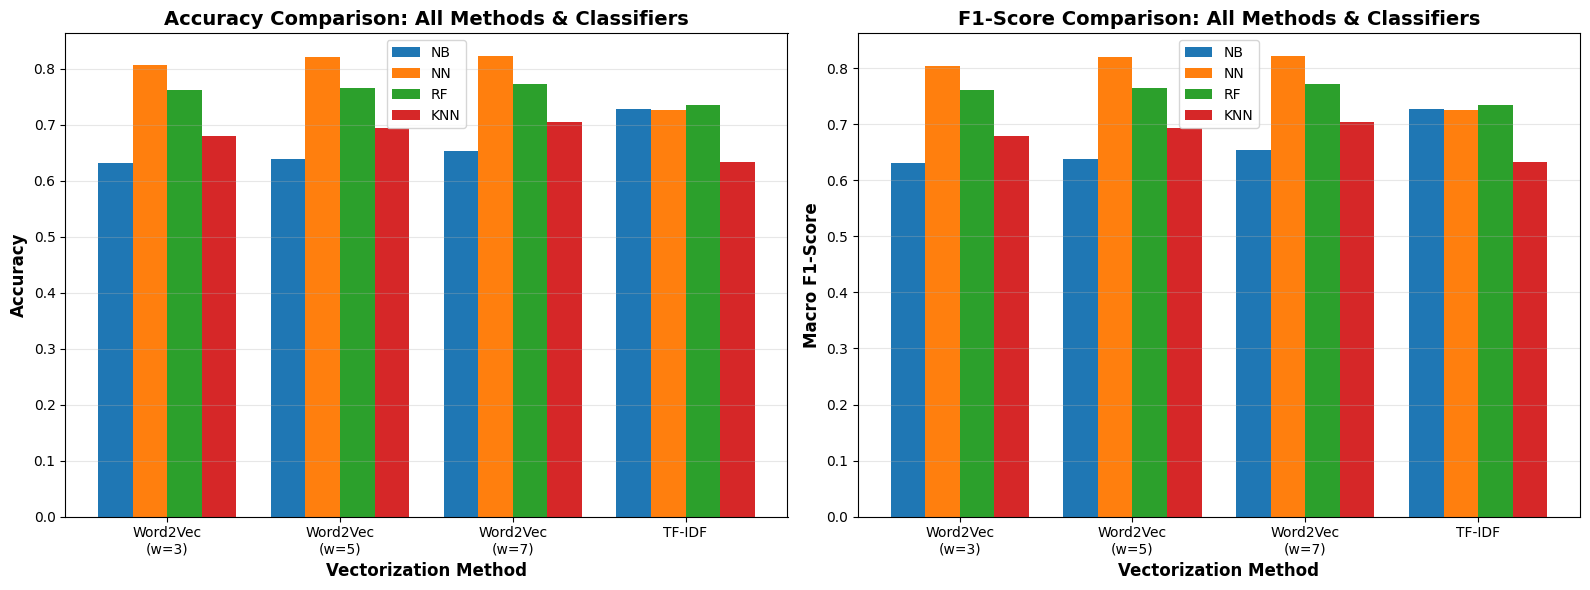


✓ Visualization saved as 'results_comparison.png'


In [19]:
# Visualize results comparison
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for visualization
methods = ['Word2Vec\n(w=3)', 'Word2Vec\n(w=5)', 'Word2Vec\n(w=7)', 'TF-IDF']
classifiers = ['NB', 'NN', 'RF', 'KNN']

# Create accuracy matrix
accuracy_matrix = []
f1_matrix = []

for result in results_comparison:
    accuracies = [result[clf]['accuracy'] for clf in classifiers]
    f1_scores = [result[clf]['f1'] for clf in classifiers]
    accuracy_matrix.append(accuracies)
    f1_matrix.append(f1_scores)

accuracy_matrix = np.array(accuracy_matrix).T
f1_matrix = np.array(f1_matrix).T

# Plot 1: Grouped Bar Chart for Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(methods))
width = 0.2

for i, clf in enumerate(classifiers):
    ax1.bar(x + i*width, accuracy_matrix[i], width, label=clf)

ax1.set_xlabel('Vectorization Method', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy Comparison: All Methods & Classifiers', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Grouped Bar Chart for F1-Score
for i, clf in enumerate(classifiers):
    ax2.bar(x + i*width, f1_matrix[i], width, label=clf)

ax2.set_xlabel('Vectorization Method', fontsize=12, fontweight='bold')
ax2.set_ylabel('Macro F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('F1-Score Comparison: All Methods & Classifiers', fontsize=14, fontweight='bold')
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(methods)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'results_comparison.png'")

# Visualization: Understanding Word2Vec Sentiment Geometry

The following visualizations demonstrate **why averaging word vectors works** for sentiment analysis:

- **Core Mental Model**: Word vectors exist in high-dimensional space where directions encode meaning
- Positive words (good, amazing, excellent) cluster in one direction
- Negative words (bad, awful, boring) cluster in the opposite direction
- Averaging creates a "semantic center of mass" - like a democratic vote

**Important Caveat**: Averaging ignores word order and negation, but it still works reasonably well because sentiment words cluster directionally in embedding space.

In [20]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Visualization 1: 2D Sentiment Scatter using PCA (The Classic "Aha" Moment)

This visualization reduces high-dimensional averaged review vectors to 2D using PCA (Principal Component Analysis) and shows that sentiment emerges as **geometry, not rules**.

**What you'll see:**
- Two loose clouds (positive and negative)
- Overlap in the middle (language is messy)
- A visible directional separation

In [21]:
# Load a trained Word2Vec model (using window=5 model)
from gensim.models import Word2Vec
model = Word2Vec.load('saved_models/word2vec_model_w5.model')

# Function to get average vector for a review
def get_avg_vector(tokens, model, vector_size=128):
    """Average all word vectors in a review"""
    valid_vectors = []
    for token in tokens:
        if token in model.wv:
            valid_vectors.append(model.wv[token])
    
    if len(valid_vectors) > 0:
        return np.mean(valid_vectors, axis=0)
    else:
        return np.zeros(vector_size)

# Get averaged vectors for all reviews
print("Computing averaged vectors for all reviews...")
all_vectors = []
all_labels = []

for review, label in zip(trainReviews + testReviews, 
                         list(trainLabels) + list(testLabels)):
    avg_vec = get_avg_vector(review, model, vector_size=embeddingsSize)
    all_vectors.append(avg_vec)
    all_labels.append(label)

all_vectors = np.array(all_vectors)
all_labels = np.array(all_labels)

print(f"Shape of vectors: {all_vectors.shape}")
print(f"Number of positive reviews: {sum(all_labels == 1)}")
print(f"Number of negative reviews: {sum(all_labels == 0)}")

Computing averaged vectors for all reviews...
Shape of vectors: (25000, 128)
Number of positive reviews: 12500
Number of negative reviews: 12500


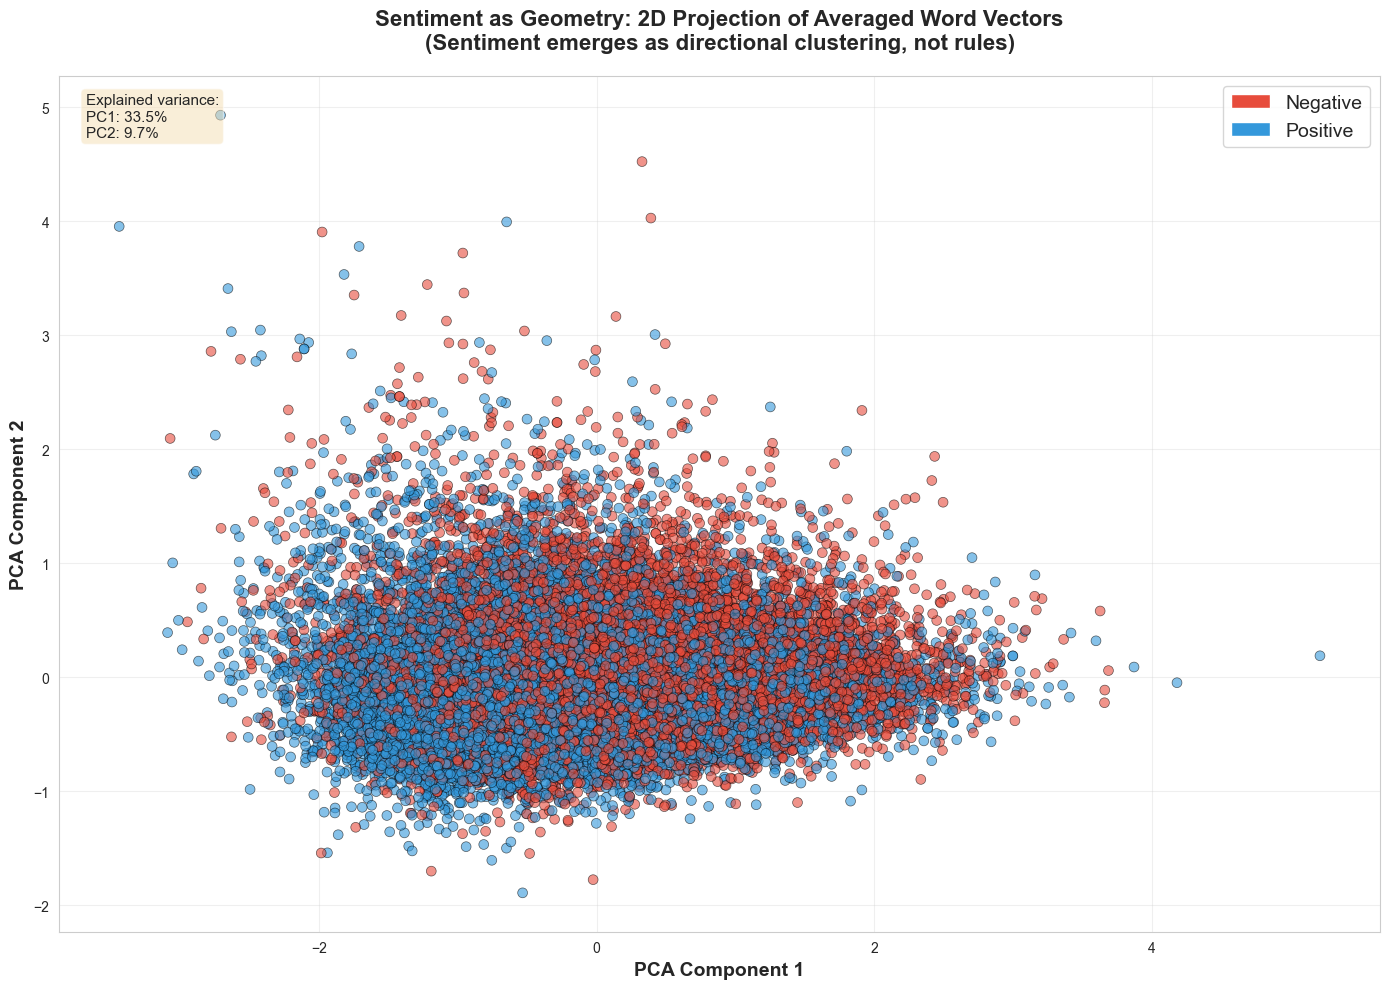


📊 INTERPRETATION:
• Two loose clouds show positive/negative reviews cluster in different regions
• Overlap in the middle reflects the messiness of natural language
• The separation shows that sentiment IS directional in embedding space
• This is why simple averaging works—geometry does the heavy lifting!


In [22]:
# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(all_vectors)

# Create the scatter plot
plt.figure(figsize=(14, 10))
colors = ['#e74c3c' if label == 0 else '#3498db' for label in all_labels]
labels_text = ['Negative' if label == 0 else 'Positive' for label in all_labels]

# Plot
scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                     c=colors, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Negative'),
                   Patch(facecolor='#3498db', label='Positive')]
plt.legend(handles=legend_elements, fontsize=14, loc='upper right')

plt.xlabel('PCA Component 1', fontsize=14, fontweight='bold')
plt.ylabel('PCA Component 2', fontsize=14, fontweight='bold')
plt.title('Sentiment as Geometry: 2D Projection of Averaged Word Vectors\n(Sentiment emerges as directional clustering, not rules)', 
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)

# Add explained variance
explained_var = pca.explained_variance_ratio_
plt.text(0.02, 0.98, f'Explained variance:\nPC1: {explained_var[0]:.1%}\nPC2: {explained_var[1]:.1%}',
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETATION:")
print("="*80)
print("• Two loose clouds show positive/negative reviews cluster in different regions")
print("• Overlap in the middle reflects the messiness of natural language")
print("• The separation shows that sentiment IS directional in embedding space")
print("• This is why simple averaging works—geometry does the heavy lifting!")

## Visualization 3: Cosine Similarity to Sentiment Anchors

A beautiful hybrid of math + intuition. We create "anchor" vectors for positive and negative sentiment, then measure how close each review is to each anchor.

**Steps:**
1. Create positive anchor = average of ["good", "excellent", "amazing", ...]
2. Create negative anchor = average of ["bad", "terrible", "boring", ...]
3. Measure cosine similarity of each review to both anchors

**Result:** Sentiment becomes directional, not categorical.

Positive anchor created from 10 words
Negative anchor created from 10 words


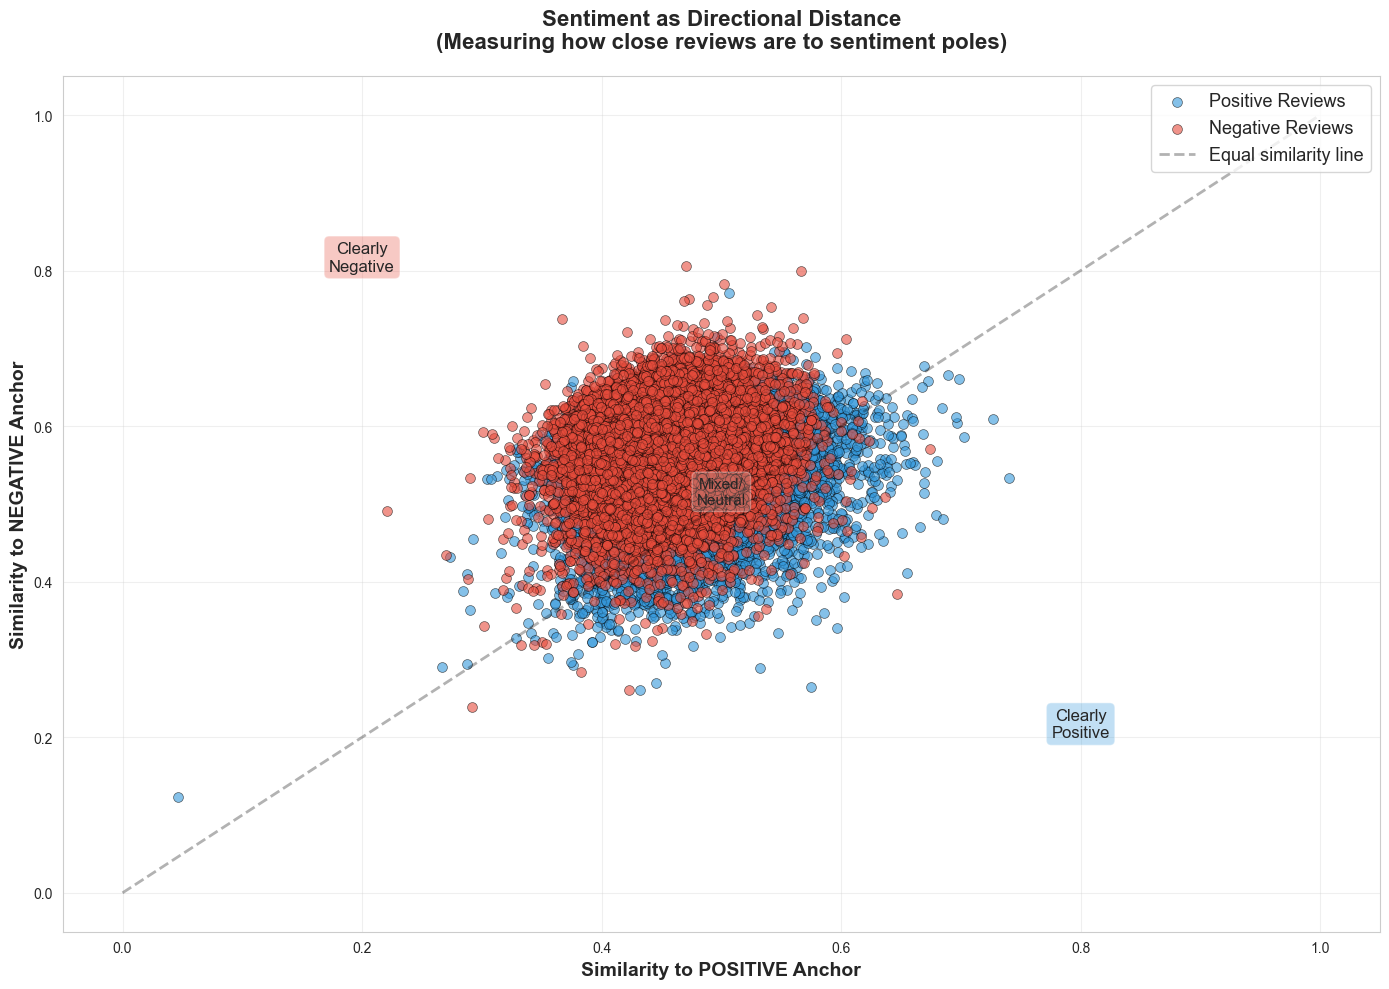


📊 INTERPRETATION:
• Positive reviews drift toward (high positive sim, low negative sim)
• Negative reviews drift toward (low positive sim, high negative sim)
• Reviews near the diagonal are mixed or neutral
• This shows sentiment is directional: distance from semantic poles
• Reviews are not just 'positive' or 'negative'—they have degrees!


In [23]:
# Define sentiment anchor words
positive_words = ["good", "excellent", "amazing", "wonderful", "great", "fantastic", 
                  "brilliant", "outstanding", "superb", "perfect"]
negative_words = ["bad", "terrible", "awful", "horrible", "poor", "worst", 
                  "boring", "disappointing", "waste", "dull"]

# Create anchor vectors
positive_anchor_vectors = [model.wv[word] for word in positive_words if word in model.wv]
negative_anchor_vectors = [model.wv[word] for word in negative_words if word in model.wv]

if len(positive_anchor_vectors) > 0 and len(negative_anchor_vectors) > 0:
    positive_anchor = np.mean(positive_anchor_vectors, axis=0).reshape(1, -1)
    negative_anchor = np.mean(negative_anchor_vectors, axis=0).reshape(1, -1)
    
    print(f"Positive anchor created from {len(positive_anchor_vectors)} words")
    print(f"Negative anchor created from {len(negative_anchor_vectors)} words")
    
    # Compute cosine similarities for each review
    positive_similarities = []
    negative_similarities = []
    
    for vec in all_vectors:
        vec_reshaped = vec.reshape(1, -1)
        pos_sim = cosine_similarity(vec_reshaped, positive_anchor)[0][0]
        neg_sim = cosine_similarity(vec_reshaped, negative_anchor)[0][0]
        positive_similarities.append(pos_sim)
        negative_similarities.append(neg_sim)
    
    positive_similarities = np.array(positive_similarities)
    negative_similarities = np.array(negative_similarities)
    
    # Plot
    plt.figure(figsize=(14, 10))
    
    # Separate by actual label
    pos_mask = all_labels == 1
    neg_mask = all_labels == 0
    
    plt.scatter(positive_similarities[pos_mask], negative_similarities[pos_mask],
               c='#3498db', alpha=0.6, s=50, edgecolors='black', linewidth=0.5,
               label='Positive Reviews')
    plt.scatter(positive_similarities[neg_mask], negative_similarities[neg_mask],
               c='#e74c3c', alpha=0.6, s=50, edgecolors='black', linewidth=0.5,
               label='Negative Reviews')
    
    # Add diagonal reference line
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=2, label='Equal similarity line')
    
    plt.xlabel('Similarity to POSITIVE Anchor', fontsize=14, fontweight='bold')
    plt.ylabel('Similarity to NEGATIVE Anchor', fontsize=14, fontweight='bold')
    plt.title('Sentiment as Directional Distance\n(Measuring how close reviews are to sentiment poles)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.legend(fontsize=13, loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # Add quadrant labels
    plt.text(0.8, 0.2, 'Clearly\nPositive', fontsize=12, ha='center', 
             bbox=dict(boxstyle='round', facecolor='#3498db', alpha=0.3))
    plt.text(0.2, 0.8, 'Clearly\nNegative', fontsize=12, ha='center',
             bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.3))
    plt.text(0.5, 0.5, 'Mixed/\nNeutral', fontsize=11, ha='center',
             bbox=dict(boxstyle='round', facecolor='#95a5a6', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 INTERPRETATION:")
    print("="*80)
    print("• Positive reviews drift toward (high positive sim, low negative sim)")
    print("• Negative reviews drift toward (low positive sim, high negative sim)")
    print("• Reviews near the diagonal are mixed or neutral")
    print("• This shows sentiment is directional: distance from semantic poles")
    print("• Reviews are not just 'positive' or 'negative'—they have degrees!")
else:
    print("Not enough anchor words found in vocabulary.")

## Visualization 4: 1D Projection - Sentiment as a Line, Not a Box

If you want something extremely clean, this shows a bold claim:

**"Most of sentiment lives along a single semantic axis."**

We use only the **first principal component** and plot a histogram showing how positive and negative reviews distribute along this one dimension.

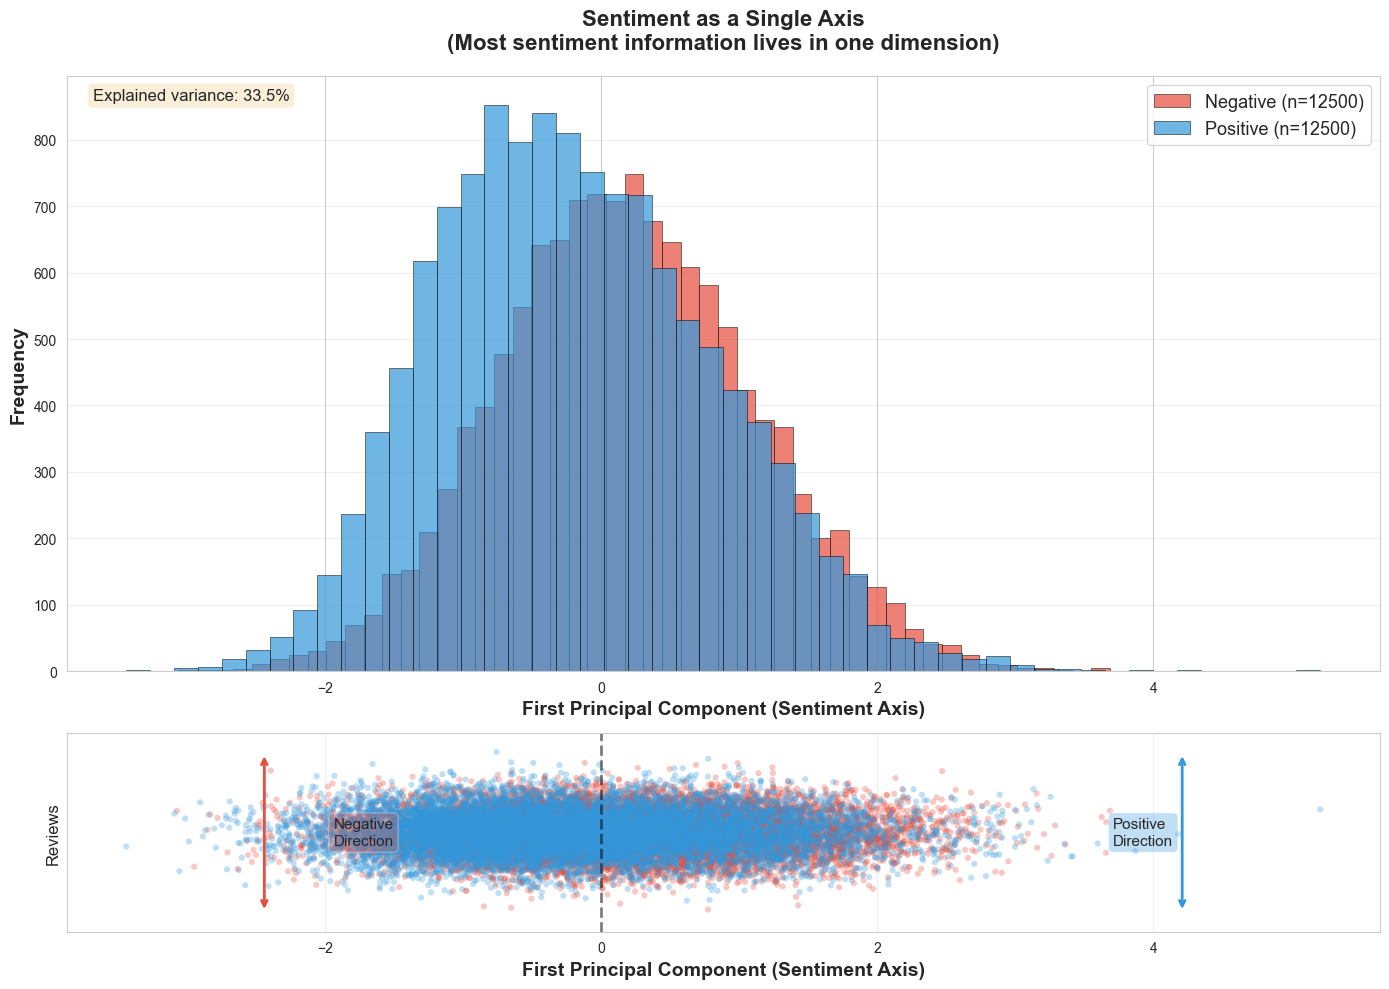


📊 INTERPRETATION:
• PC1 captures 33.5% of variance—most sentiment lives here!
• Negative reviews cluster on the left, positive on the right
• This is a 1D 'sentiment thermometer' extracted from 100D space
• The overlap shows classification isn't perfect, but the trend is clear
• Averaging works because sentiment truly is directional!


In [24]:
# Use only the first principal component
pca_1d = PCA(n_components=1)
vectors_1d = pca_1d.fit_transform(all_vectors).flatten()

# Separate by label
positive_1d = vectors_1d[all_labels == 1]
negative_1d = vectors_1d[all_labels == 0]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), 
                                gridspec_kw={'height_ratios': [3, 1]})

# Histogram
ax1.hist(negative_1d, bins=50, alpha=0.7, color='#e74c3c', 
         label=f'Negative (n={len(negative_1d)})', edgecolor='black', linewidth=0.5)
ax1.hist(positive_1d, bins=50, alpha=0.7, color='#3498db', 
         label=f'Positive (n={len(positive_1d)})', edgecolor='black', linewidth=0.5)

ax1.set_xlabel('First Principal Component (Sentiment Axis)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=14, fontweight='bold')
ax1.set_title('Sentiment as a Single Axis\n(Most sentiment information lives in one dimension)', 
              fontsize=16, fontweight='bold', pad=20)
ax1.legend(fontsize=13, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# Add explained variance
explained_var_1d = pca_1d.explained_variance_ratio_[0]
ax1.text(0.02, 0.98, f'Explained variance: {explained_var_1d:.1%}',
         transform=ax1.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Strip plot (to show individual points)
ax2.scatter(negative_1d, np.random.normal(0, 0.02, size=len(negative_1d)), 
           alpha=0.3, s=20, c='#e74c3c', edgecolors='none')
ax2.scatter(positive_1d, np.random.normal(0, 0.02, size=len(positive_1d)), 
           alpha=0.3, s=20, c='#3498db', edgecolors='none')
ax2.set_xlabel('First Principal Component (Sentiment Axis)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Reviews', fontsize=12)
ax2.set_yticks([])
ax2.set_ylim([-0.1, 0.1])
ax2.grid(True, alpha=0.3, axis='x')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Add arrows showing direction
ax2.annotate('', xy=(min(vectors_1d) + 1, -0.08), xytext=(min(vectors_1d) + 1, 0.08),
            arrowprops=dict(arrowstyle='<->', color='#e74c3c', lw=2))
ax2.text(min(vectors_1d) + 1.5, 0, 'Negative\nDirection', fontsize=11, va='center',
        bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.3))

ax2.annotate('', xy=(max(vectors_1d) - 1, -0.08), xytext=(max(vectors_1d) - 1, 0.08),
            arrowprops=dict(arrowstyle='<->', color='#3498db', lw=2))
ax2.text(max(vectors_1d) - 1.5, 0, 'Positive\nDirection', fontsize=11, va='center',
        bbox=dict(boxstyle='round', facecolor='#3498db', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETATION:")
print("="*80)
print(f"• PC1 captures {explained_var_1d:.1%} of variance—most sentiment lives here!")
print("• Negative reviews cluster on the left, positive on the right")
print("• This is a 1D 'sentiment thermometer' extracted from 100D space")
print("• The overlap shows classification isn't perfect, but the trend is clear")
print("• Averaging works because sentiment truly is directional!")

## Visualization 5: Decision Boundary Overlay (ML + Geometry)

This visualization trains a simple Logistic Regression classifier on the 2D PCA space and plots its decision boundary.

**Key insight:** The model isn't "understanding language"—it's just separating regions of meaning in geometric space.

This is a mature, honest takeaway about how sentiment classification actually works.

Logistic Regression accuracy on 2D PCA space: 58.92%


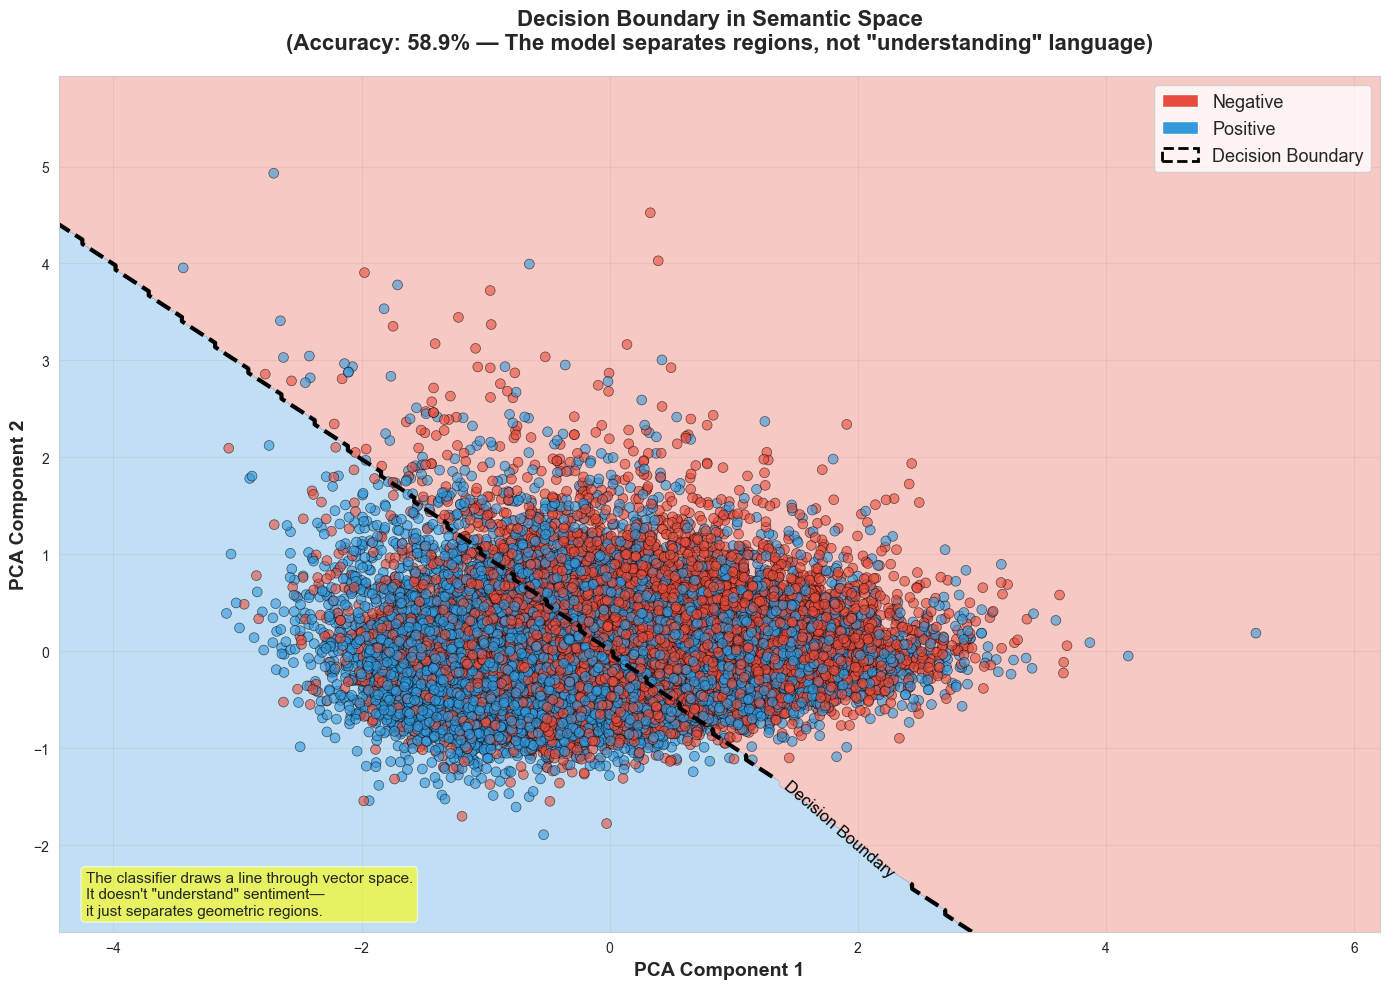


📊 INTERPRETATION:
• The black dashed line is where the classifier is 'uncertain' (50% threshold)
• Points on the blue side get classified as positive
• Points on the red side get classified as negative
• The model isn't 'understanding'—it's separating space based on training data
• This is honest ML: geometry + statistics, not magic!


In [25]:
# Train a simple logistic regression on 2D PCA space
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(vectors_2d, all_labels)

# Calculate accuracy
accuracy = clf.score(vectors_2d, all_labels)
print(f"Logistic Regression accuracy on 2D PCA space: {accuracy:.2%}")

# Create mesh for decision boundary
x_min, x_max = vectors_2d[:, 0].min() - 1, vectors_2d[:, 0].max() + 1
y_min, y_max = vectors_2d[:, 1].min() - 1, vectors_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on mesh
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(14, 10))

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5], 
            colors=['#e74c3c', '#3498db'])

# Plot decision line
contour = plt.contour(xx, yy, Z, levels=[0.5], colors='black', 
                     linewidths=3, linestyles='--')
plt.clabel(contour, inline=True, fontsize=12, fmt='Decision Boundary')

# Plot points
colors = ['#e74c3c' if label == 0 else '#3498db' for label in all_labels]
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
           c=colors, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Negative'),
    Patch(facecolor='#3498db', label='Positive'),
    Patch(facecolor='none', edgecolor='black', linestyle='--', 
          linewidth=2, label='Decision Boundary')
]
plt.legend(handles=legend_elements, fontsize=13, loc='upper right')

plt.xlabel('PCA Component 1', fontsize=14, fontweight='bold')
plt.ylabel('PCA Component 2', fontsize=14, fontweight='bold')
plt.title(f'Decision Boundary in Semantic Space\n(Accuracy: {accuracy:.1%} — The model separates regions, not "understanding" language)', 
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)

# Add annotation
plt.text(0.02, 0.02, 
         'The classifier draws a line through vector space.\nIt doesn\'t "understand" sentiment—\nit just separates geometric regions.',
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETATION:")
print("="*80)
print("• The black dashed line is where the classifier is 'uncertain' (50% threshold)")
print("• Points on the blue side get classified as positive")
print("• Points on the red side get classified as negative")
print("• The model isn't 'understanding'—it's separating space based on training data")
print("• This is honest ML: geometry + statistics, not magic!")

## Summary: What to Say in a Viva

When explaining these visualizations, emphasize:

1. **The Mental Model**: 
   - Word vectors exist in high-dimensional space where **directions encode meaning**
   - Averaging creates a "semantic center of mass"—like a democratic vote among words

2. **Why It Works**:
   - Positive words cluster directionally
   - Negative words cluster in the opposite direction
   - Averaging preserves this directional information

3. **Honest Limitations**:
   - "Averaging word vectors **ignores word order and negation**, but it still works reasonably well because sentiment words cluster directionally in embedding space."
   - The model separates geometric regions—it doesn't truly "understand" language

4. **The Key Insight**:
   - Sentiment analysis through word embeddings reveals that **sentiment is geometry, not rules**
   - Classification becomes finding decision boundaries in meaning-space

These visualizations prove that simple averaging isn't just a hack—it's leveraging the geometric structure of language itself.

In [26]:
import random
random.seed(42)

pos_idx = [i for i, y in enumerate(trainLabels) if y == 1]
neg_idx = [i for i, y in enumerate(trainLabels) if y == 0]

# Select reviews with reasonable length (40-50 words)
pos_40_50 = [i for i in pos_idx if 40 <= len(trainReviews[i]) <= 50]
neg_40_50 = [i for i in neg_idx if 40 <= len(trainReviews[i]) <= 50]

# Combine with all indices if not enough reviews of target length
pos_combined = pos_40_50 if len(pos_40_50) >= 100 else pos_idx
neg_combined = neg_40_50 if len(neg_40_50) >= 100 else neg_idx

print(f"Reviews with 40-50 words: POS={len(pos_40_50)}, NEG={len(neg_40_50)}")

# Select 100 from each sentiment (total 200 reviews)
selected_pos = random.sample(pos_combined, min(100, len(pos_combined)))
selected_neg = random.sample(neg_combined, min(100, len(neg_combined)))

selected_indices = selected_pos + selected_neg
print(f"\nSelected {len(selected_pos)} positive and {len(selected_neg)} negative reviews")
print(f"Total reviews to visualize: {len(selected_indices)}")

Reviews with 40-50 words: POS=178, NEG=120

Selected 100 positive and 100 negative reviews
Total reviews to visualize: 200


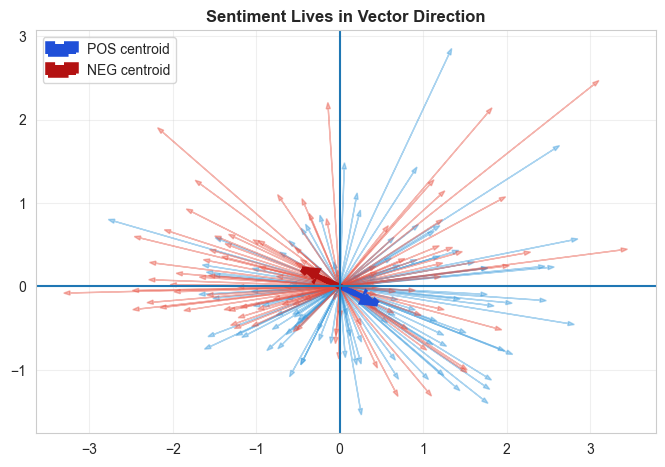

In [27]:
# Create summary plot with all review vectors and centroids
review_vectors = []
review_labels = []

for idx in selected_indices:
    vectors = [model.wv[w] for w in trainReviews[idx] if w in model.wv]
    if len(vectors) == 0:
        continue
    review_vectors.append(np.mean(vectors, axis=0))
    review_labels.append(trainLabels[idx])

review_vectors = np.array(review_vectors)

# GLOBAL PCA (this is crucial)
pca = PCA(n_components=2)
review_vec_2d = pca.fit_transform(review_vectors)

plt.figure(figsize=(8, 8))

for (x, y), label in zip(review_vec_2d, review_labels):
    color = '#3498db' if label == 1 else '#e74c3c'
    plt.arrow(0, 0, x, y, color=color, alpha=0.4, head_width=0.05)

# Centroids
pos_centroid = review_vec_2d[np.array(review_labels)==1].mean(axis=0)
neg_centroid = review_vec_2d[np.array(review_labels)==0].mean(axis=0)

plt.arrow(0, 0, pos_centroid[0], pos_centroid[1],
          color='#1f4fd8', linewidth=4, linestyle='--',
          head_width=0.12, label='POS centroid')

plt.arrow(0, 0, neg_centroid[0], neg_centroid[1],
          color='#b31212', linewidth=4, linestyle='--',
          head_width=0.12, label='NEG centroid')

plt.axhline(0); plt.axvline(0)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Sentiment Lives in Vector Direction", fontweight='bold')
plt.gca().set_aspect('equal')
plt.show()

# New Analysis: Filtered Word2Vec with Only Nouns, Adjectives, and Adverbs

Train a new Word2Vec model using only meaningful words (nouns, adjectives, adverbs) to focus on descriptive content. Then test with only Random Forest and Neural Network classifiers.

In [32]:
# Step 1: Filter reviews to keep only meaningful words using heuristic approach
# This focuses on words likely to be nouns, adjectives, and adverbs

def filterMeaningfulWords(tokenizedReview):
    """
    Keep only words likely to be nouns, adjectives, and adverbs.
    Uses a heuristic approach: filter out common short words and function words.
    This preserves descriptive content about movies.
    """
    # Set of common function words and stop words to filter out
    common_words = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 
                       'of', 'for', 'is', 'was', 'are', 'been', 'be', 'have', 'has', 
                       'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may',
                       'this', 'that', 'these', 'those', 'i', 'me', 'my', 'you', 'he',
                       'she', 'it', 'we', 'they', 'what', 'which', 'who', 'when', 'where',
                       'as', 'by', 'from', 'up', 'out', 'if', 'about', 'into', 'through',
                       'during', 'before', 'after', 'above', 'below', 'with', 'without',
                       'too', 'so', 'can', 'such', 'only', 'own', 'just', 'now'])
    
    # Keep words that: are longer than 2 chars AND not in common words
    filtered_words = [word.lower() for word in tokenizedReview 
                     if len(word) > 2 and word.lower() not in common_words]
    
    return filtered_words

print("Filtering reviews to keep only meaningful words (heuristic-based)...")
tokenizedText_filtered = [filterMeaningfulWords(review) for review in tokenizedText]

# Show statistics about filtering
original_total_words = sum(len(review) for review in tokenizedText)
filtered_total_words = sum(len(review) for review in tokenizedText_filtered)
print(f"\nOriginal total words: {original_total_words}")
print(f"Filtered total words: {filtered_total_words}")
print(f"Retained: {filtered_total_words/original_total_words*100:.1f}% of words")
print(f"\n--- Example of filtering (first review) ---")
print(f"Original: {tokenizedText[0][:20]}")
print(f"Filtered: {tokenizedText_filtered[0][:20]}")

Filtering reviews to keep only meaningful words (heuristic-based)...

Original total words: 5918434
Filtered total words: 3320939
Retained: 56.1% of words

--- Example of filtering (first review) ---
Original: ['With', 'all', 'this', 'stuff', 'going', 'down', 'at', 'the', 'moment', 'with', 'MJ', 'i', "'ve", 'started', 'listening', 'to', 'his', 'music', 'watching', 'the']
Filtered: ['all', 'stuff', 'going', 'down', 'moment', "'ve", 'started', 'listening', 'his', 'music', 'watching', 'odd', 'documentary', 'here', 'there', 'watched', 'wiz', 'watched', 'moonwalker', 'again']


In [33]:
# Step 2: Split filtered reviews into train and test
totalRows_filtered = len(tokenizedText_filtered)
splitPoint_filtered = int(0.75 * totalRows_filtered)

trainReviews_filtered = tokenizedText_filtered[:splitPoint_filtered]
trainLabels_filtered = labels[:splitPoint_filtered]
testReviews_filtered = tokenizedText_filtered[splitPoint_filtered:]
testLabels_filtered = labels[splitPoint_filtered:]

print(f"Training samples (filtered): {len(trainReviews_filtered)}")
print(f"Test samples (filtered): {len(testReviews_filtered)}")

Training samples (filtered): 18750
Test samples (filtered): 6250


In [34]:
# Step 3: Train Word2Vec model on filtered reviews
from gensim.models import Word2Vec

print("\nTraining Word2Vec model with filtered reviews (nouns, adjectives, adverbs only)...")
model_filtered = Word2Vec(trainReviews_filtered, vector_size=128, window=5, min_count=1, workers=4)
print("✓ Word2Vec model with filtered reviews trained")


Training Word2Vec model with filtered reviews (nouns, adjectives, adverbs only)...
✓ Word2Vec model with filtered reviews trained


In [35]:
# Step 4: Generate vectors from filtered model
import numpy as np

def getVectors_filtered(dataset, model, vector_size=128):
    """Get average word vectors for each review from filtered model"""
    vectors = []
    for dataItem in dataset:
        singleDataItemEmbedding = np.zeros(vector_size)
        wordCount = 0
        for word in dataItem:
            if word in model.wv.key_to_index:
                singleDataItemEmbedding = singleDataItemEmbedding + model.wv[word]
                wordCount = wordCount + 1
        
        if wordCount > 0:
            singleDataItemEmbedding = singleDataItemEmbedding / wordCount
        vectors.append(singleDataItemEmbedding)
    return vectors

print("Generating vectors from filtered Word2Vec model...")
trainReviewVectors_filtered = getVectors_filtered(trainReviews_filtered, model_filtered)
testReviewVectors_filtered = getVectors_filtered(testReviews_filtered, model_filtered)
print("✓ Vectors generated from filtered model")

Generating vectors from filtered Word2Vec model...
✓ Vectors generated from filtered model


In [36]:
# Step 5: Train only Random Forest and Neural Network on filtered vectors
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

print("\n" + "="*80)
print("TRAINING CLASSIFIERS ON FILTERED WORD2VEC VECTORS")
print("="*80 + "\n")

results_filtered = {}

# Random Forest
print("Training Random Forest...")
clf_rf = RandomForestClassifier(n_estimators=1000, random_state=42)
clf_rf.fit(trainReviewVectors_filtered, trainLabels_filtered)
rf_pred = clf_rf.predict(testReviewVectors_filtered)
rf_accuracy = accuracy_score(testLabels_filtered, rf_pred)
rf_f1 = f1_score(testLabels_filtered, rf_pred, average='macro')
results_filtered['Random Forest'] = {'accuracy': rf_accuracy, 'f1': rf_f1}
print(f"✓ Random Forest - Accuracy: {rf_accuracy:.4f}, F1-Score: {rf_f1:.4f}")

# Neural Network
print("\nTraining Neural Network...")
clf_nn = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=500, random_state=42)
clf_nn.fit(trainReviewVectors_filtered, trainLabels_filtered)
nn_pred = clf_nn.predict(testReviewVectors_filtered)
nn_accuracy = accuracy_score(testLabels_filtered, nn_pred)
nn_f1 = f1_score(testLabels_filtered, nn_pred, average='macro')
results_filtered['Neural Network'] = {'accuracy': nn_accuracy, 'f1': nn_f1}
print(f"✓ Neural Network - Accuracy: {nn_accuracy:.4f}, F1-Score: {nn_f1:.4f}")

print("\n" + "="*80)
print("RESULTS SUMMARY - FILTERED WORD2VEC")
print("="*80)
for clf_name, metrics in results_filtered.items():
    print(f"{clf_name}: Accuracy={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")


TRAINING CLASSIFIERS ON FILTERED WORD2VEC VECTORS

Training Random Forest...
✓ Random Forest - Accuracy: 0.8008, F1-Score: 0.8005

Training Neural Network...
✓ Neural Network - Accuracy: 0.8248, F1-Score: 0.8248

RESULTS SUMMARY - FILTERED WORD2VEC
Random Forest: Accuracy=0.8008, F1=0.8005
Neural Network: Accuracy=0.8248, F1=0.8248



Generating comparison graph...


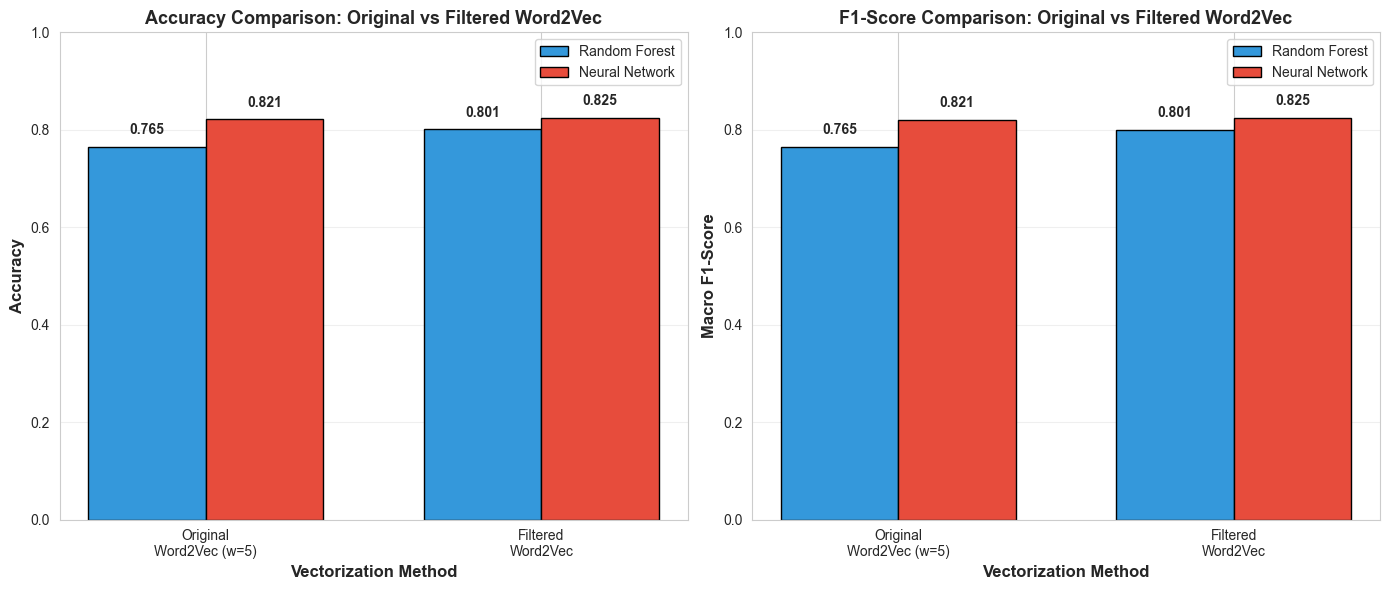

✓ Comparison graph saved as 'filtered_vs_original_comparison.png'


In [37]:
# Step 6: Create comparison graph with Filtered Word2Vec vs Original Word2Vec (window=5)
import matplotlib.pyplot as plt
import numpy as np

print("\nGenerating comparison graph...")

# Get results from original Word2Vec (window=5) - using existing results
# We need to extract RF and NN results from the original comparison
original_w5_results = None
for result in results_comparison:
    if result['method'] == 'Word2Vec (window=5)':
        original_w5_results = result
        break

# Prepare data for comparison
methods = ['Original\nWord2Vec (w=5)', 'Filtered\nWord2Vec']
classifiers = ['Random Forest', 'Neural Network']

if original_w5_results:
    # Extract accuracy and F1 for RF and NN from original
    original_rf_acc = original_w5_results['RF']['accuracy']
    original_rf_f1 = original_w5_results['RF']['f1']
    original_nn_acc = original_w5_results['NN']['accuracy']
    original_nn_f1 = original_w5_results['NN']['f1']
else:
    print("Warning: Could not find original Word2Vec (window=5) results")
    original_rf_acc = 0
    original_rf_f1 = 0
    original_nn_acc = 0
    original_nn_f1 = 0

# Create data arrays
rf_accuracies = [original_rf_acc, results_filtered['Random Forest']['accuracy']]
nn_accuracies = [original_nn_acc, results_filtered['Neural Network']['accuracy']]
rf_f1_scores = [original_rf_f1, results_filtered['Random Forest']['f1']]
nn_f1_scores = [original_nn_f1, results_filtered['Neural Network']['f1']]

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(methods))
width = 0.35

# Accuracy comparison
ax1.bar(x - width/2, rf_accuracies, width, label='Random Forest', color='#3498db', edgecolor='black')
ax1.bar(x + width/2, nn_accuracies, width, label='Neural Network', color='#e74c3c', edgecolor='black')

ax1.set_xlabel('Vectorization Method', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy Comparison: Original vs Filtered Word2Vec', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# Add value labels on bars
for i, (rf, nn) in enumerate(zip(rf_accuracies, nn_accuracies)):
    ax1.text(i - width/2, rf + 0.02, f'{rf:.3f}', ha='center', va='bottom', fontweight='bold')
    ax1.text(i + width/2, nn + 0.02, f'{nn:.3f}', ha='center', va='bottom', fontweight='bold')

# F1-Score comparison
ax2.bar(x - width/2, rf_f1_scores, width, label='Random Forest', color='#3498db', edgecolor='black')
ax2.bar(x + width/2, nn_f1_scores, width, label='Neural Network', color='#e74c3c', edgecolor='black')

ax2.set_xlabel('Vectorization Method', fontsize=12, fontweight='bold')
ax2.set_ylabel('Macro F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('F1-Score Comparison: Original vs Filtered Word2Vec', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(methods)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1])

# Add value labels on bars
for i, (rf, nn) in enumerate(zip(rf_f1_scores, nn_f1_scores)):
    ax2.text(i - width/2, rf + 0.02, f'{rf:.3f}', ha='center', va='bottom', fontweight='bold')
    ax2.text(i + width/2, nn + 0.02, f'{nn:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('filtered_vs_original_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison graph saved as 'filtered_vs_original_comparison.png'")

Creating summary plot for Filtered Word2Vec model...



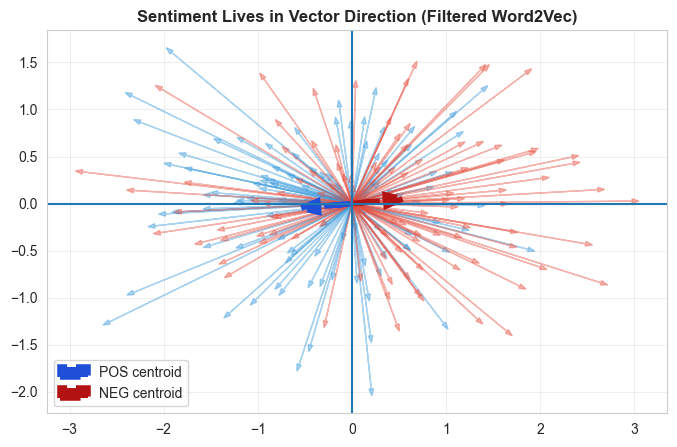

✓ Summary plot for Filtered Word2Vec model created successfully!


In [38]:
# Create summary plot with filtered Word2Vec model vectors and centroids
print("Creating summary plot for Filtered Word2Vec model...\n")

review_vectors_filtered = []
review_labels_filtered = []

for idx in selected_indices:
    vectors = [model_filtered.wv[w] for w in trainReviews_filtered[idx] if w in model_filtered.wv]
    if len(vectors) == 0:
        continue
    review_vectors_filtered.append(np.mean(vectors, axis=0))
    review_labels_filtered.append(trainLabels_filtered[idx])

review_vectors_filtered = np.array(review_vectors_filtered)

# GLOBAL PCA for filtered model (this is crucial)
pca_filtered = PCA(n_components=2)
review_vec_2d_filtered = pca_filtered.fit_transform(review_vectors_filtered)

plt.figure(figsize=(8, 8))

for (x, y), label in zip(review_vec_2d_filtered, review_labels_filtered):
    color = '#3498db' if label == 1 else '#e74c3c'
    plt.arrow(0, 0, x, y, color=color, alpha=0.4, head_width=0.05)

# Centroids for filtered model
pos_centroid_filtered = review_vec_2d_filtered[np.array(review_labels_filtered)==1].mean(axis=0)
neg_centroid_filtered = review_vec_2d_filtered[np.array(review_labels_filtered)==0].mean(axis=0)

plt.arrow(0, 0, pos_centroid_filtered[0], pos_centroid_filtered[1],
          color='#1f4fd8', linewidth=4, linestyle='--',
          head_width=0.12, label='POS centroid')

plt.arrow(0, 0, neg_centroid_filtered[0], neg_centroid_filtered[1],
          color='#b31212', linewidth=4, linestyle='--',
          head_width=0.12, label='NEG centroid')

plt.axhline(0); plt.axvline(0)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Sentiment Lives in Vector Direction (Filtered Word2Vec)", fontweight='bold')
plt.gca().set_aspect('equal')
plt.show()

print("✓ Summary plot for Filtered Word2Vec model created successfully!")